# Unsupervised Learning

In this field, we work with unlabeled data. While in supervised learning we try to generalize the data based on given target data, in unsupervised learning we create our own labels.

## Clustering

Cluster - group of nearly placed instances

### K-means

This algorithm works by defining centroids of clusters.


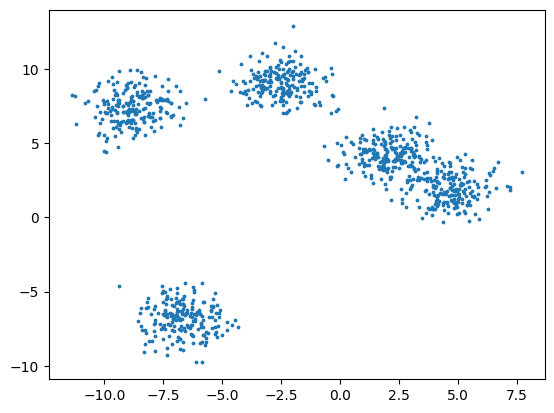

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=1000, centers=5, random_state=42)

plt.scatter(X[:, 0], X[:, 1], s=3)
plt.show()

In [2]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
kmeans.labels_[:10]

array([4, 4, 0, 4, 1, 0, 3, 1, 4, 1], dtype=int32)

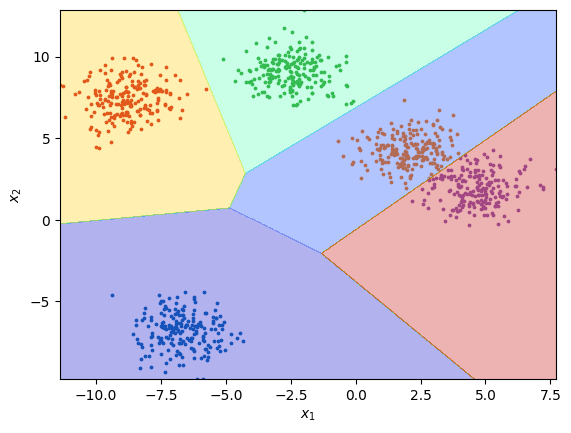

In [3]:
import numpy as np

def plot_2d_scatter_and_centers(X: np.typing.NDArray, kmeans: KMeans, resolution: int = 1000,  centers: np.typing.NDArray | None = None) -> None:
    for i in range(k):
        plt.scatter(X[:, 0][y_pred == i], X[:, 1][y_pred == i], s=3)

    X_mins = X.min(axis=0)
    X_maxs = X.max(axis=0)


    xx, yy = np.meshgrid(
        np.linspace(X_mins[0], X_maxs[0], resolution),
        np.linspace(X_mins[1], X_maxs[1], resolution)
    )

    Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(Z, alpha=0.3, extent=(X_mins[0], X_maxs[0], X_mins[1], X_maxs[1]), cmap="jet")

    if centers is not None:
        plt.scatter(centers[:, 0], centers[:, 1], marker="*", s=100, c="black")

    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")

    plt.show()

plot_2d_scatter_and_centers(X, kmeans)

In [4]:
kmeans.cluster_centers_

array([[-6.68630691, -6.81139455],
       [ 2.03639615,  4.26762858],
       [-2.50265159,  9.03963769],
       [-8.80798056,  7.40425704],
       [ 4.66534309,  1.87476184]])

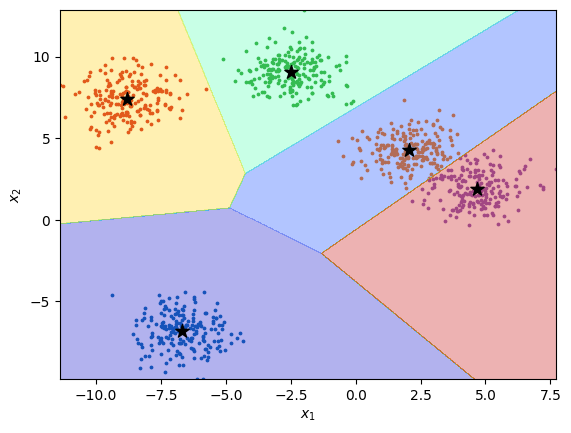

In [5]:
plot_2d_scatter_and_centers(X, kmeans, 1000, kmeans.cluster_centers_)

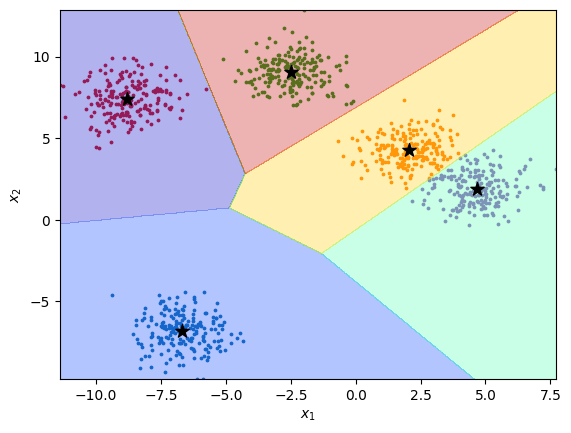

In [6]:
good_inits = np.array([
    [-8.5, 7],
    [-7.5, -6],
    [5, 0.5],
    [2.3, 4],
    [-2.3, 8.5]

])

kmeans = KMeans(n_clusters=5, init=good_inits, n_init=1)
kmeans.fit(X)
plot_2d_scatter_and_centers(X, kmeans, centers=kmeans.cluster_centers_)

In [7]:
kmeans.inertia_

1873.4290193066272

## Mini-Batch K-means

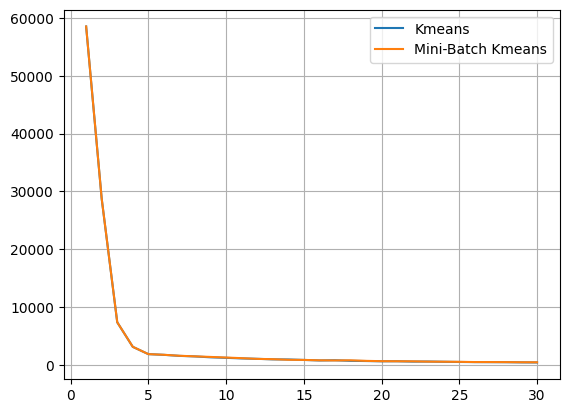

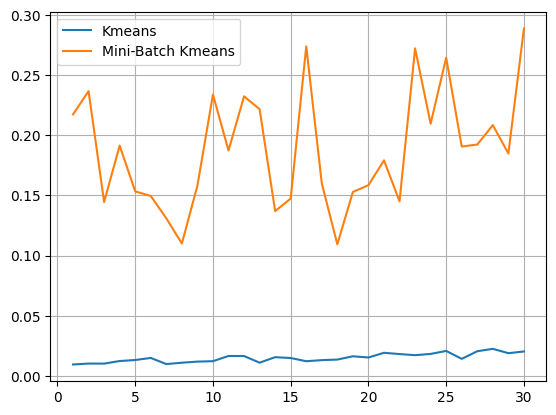

In [24]:
from sklearn.cluster import MiniBatchKMeans
import time

def plot_ks_inertia(k: int, X: np.typing.NDArray, skip_starting_k: int = 0) -> None:
    if skip_starting_k < 0:
        raise ValueError("You can't skip negative amount of instances")
    

    kmeans_plot_inertia = []
    kmeans_batch_plot_inertia = []

    for k_ in range(skip_starting_k+1, k+1):
        kmeans_batch = MiniBatchKMeans(n_clusters=k_).fit(X)
        kmeans = KMeans(n_clusters=k_).fit(X)

        kmeans_plot_inertia.append(kmeans.inertia_)
        kmeans_batch_plot_inertia.append(kmeans_batch.inertia_)
    
    plt.plot(np.arange(skip_starting_k+1, k+1), kmeans_plot_inertia, label="Kmeans")
    plt.plot(np.arange(skip_starting_k+1, k+1), kmeans_batch_plot_inertia, label="Mini-Batch Kmeans")

    plt.legend()
    plt.grid(True)
    plt.show()

def plot_ks_training_time(k: int, X: np.typing.NDArray, skip_starting_k: int = 0) -> None:
    if skip_starting_k < 0:
        raise ValueError("You can't skip negative amount of instances")
    
    kmeans_time = []
    kmeans_batch_time = []

    for k_ in range(skip_starting_k+1, k+1):
        start = time.perf_counter()
        MiniBatchKMeans(n_clusters=k_, n_init=1).fit(X)
        end = time.perf_counter()
        
        kmeans_batch_time.append(end - start)

        start = time.perf_counter()
        KMeans(n_clusters=k_, n_init=1).fit(X)
        end = time.perf_counter()

        kmeans_time.append(end - start)

    plt.plot(np.arange(skip_starting_k+1, k+1), kmeans_time, label="Kmeans")
    plt.plot(np.arange(skip_starting_k+1, k+1), kmeans_batch_time, label="Mini-Batch Kmeans")

    plt.legend()
    plt.grid(True)
    plt.show()

plot_ks_inertia(k=30, X=X, skip_starting_k=0)
plot_ks_training_time(k=30, X=X, skip_starting_k=0)